# Evaluating Skill Trends


In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

dataset = load_dataset("lukebarousse/data_jobs")
df = dataset["train"].to_pandas()

# Data Cleanup
df["job_posted_date"] = pd.to_datetime(df["job_posted_date"], errors="coerce")
df["job_skills"] = df["job_skills"].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [3]:
df_DA_CA = df[(df["job_country"] == "Canada") & (df["job_title"].str.contains("Data Analyst", case=False, na=False))].copy()

In [4]:
df_DA_CA["job_posted_month_no"] = df_DA_CA["job_posted_date"].dt.month

In [5]:
df_DA_CA_explode = df_DA_CA.explode("job_skills")

In [33]:
df_DA_CA_pivot = df_DA_CA_explode.pivot_table(index="job_posted_month_no", columns="job_skills", aggfunc="size", fill_value=0)

df_DA_CA_pivot.loc["Total"] = df_DA_CA_pivot.sum()
df_DA_CA_pivot[df_DA_CA_pivot.loc["Total"].sort_values(ascending= False).index]
df_DA_US_pivot = df_DA_CA_pivot.drop('Total')

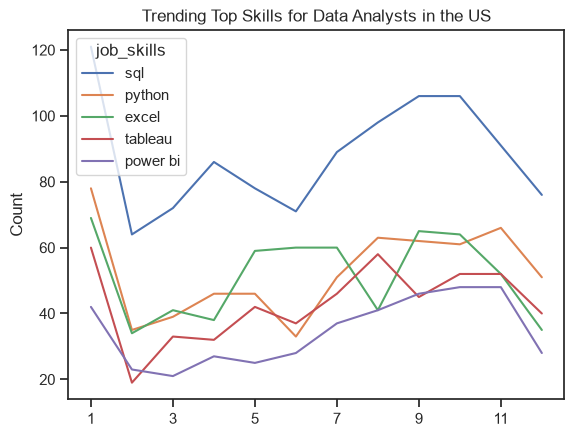

In [36]:
df_DA_CA_pivot[df_DA_CA_pivot.loc["Total"].sort_values(ascending= False).index].drop('Total').iloc[:, :5].plot(kind='line')
plt.title('Trending Top Skills for Data Analysts in the US')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

In [37]:
DA_totals = df_DA_CA.groupby("job_posted_month_no").size()

In [41]:

# divide first 12 rows of df_DA_pivot by DA_totals
df_DA_CA_percent =df_DA_CA_pivot[df_DA_CA_pivot.loc["Total"].sort_values(ascending= False).index].drop('Total').iloc[:12].div(DA_totals/100, axis=0)

# changes month number to month name
df_DA_CA_percent = df_DA_CA_percent.reset_index()
df_DA_CA_percent['job_posted_month'] = df_DA_CA_percent['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_CA_percent = df_DA_CA_percent.set_index('job_posted_month')
df_DA_CA_percent = df_DA_CA_percent.drop(columns='job_posted_month_no')

df_DA_CA_percent

job_skills,sql,python,excel,tableau,power bi,r,sas,looker,word,powerpoint,...,rust,redis,selenium,splunk,terraform,trello,twilio,watson,webex,wire
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,61.111111,39.393939,34.848485,30.303030,21.212121,22.222222,14.141414,9.595960,10.606061,9.595960,...,0.505051,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000
Feb,58.715596,32.110092,31.192661,17.431193,21.100917,12.844037,7.339450,6.422018,11.009174,7.339450,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000
Mar,59.016393,31.967213,33.606557,27.049180,17.213115,20.491803,16.393443,9.836066,11.475410,12.295082,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000
Apr,64.179104,34.328358,28.358209,23.880597,20.149254,12.686567,20.895522,9.701493,7.462687,5.970149,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000
May,60.937500,35.937500,46.093750,32.812500,19.531250,18.750000,17.187500,7.812500,7.031250,10.937500,...,0.000000,0.000000,0.000000,0.000000,0.78125,0.78125,0.000000,0.78125,0.000000,0.000000
Jun,52.205882,24.264706,44.117647,27.205882,20.588235,14.705882,8.823529,7.352941,11.029412,10.294118,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000
Jul,59.731544,34.228188,40.268456,30.872483,24.832215,16.778523,12.080537,7.382550,3.355705,4.697987,...,0.000000,0.000000,0.671141,0.671141,0.00000,0.00000,0.000000,0.00000,0.671141,0.000000
Aug,64.052288,41.176471,26.797386,37.908497,26.797386,22.875817,5.228758,13.071895,8.496732,5.228758,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000
Sep,66.666667,38.993711,40.880503,28.301887,28.930818,21.383648,11.320755,11.320755,8.176101,7.547170,...,0.000000,0.628931,0.000000,0.000000,0.00000,0.00000,0.000000,0.00000,0.000000,0.000000


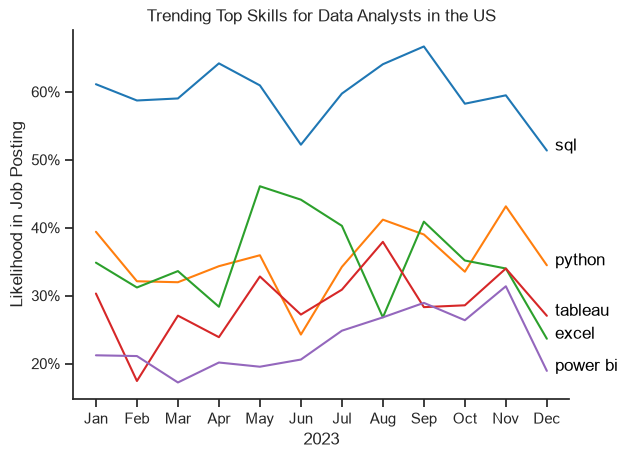

In [42]:
from matplotlib.ticker import PercentFormatter

df_plot = df_DA_CA_percent.iloc[:, :5]
sns.lineplot(data=df_plot, dashes=False, legend='full', palette='tab10')
sns.set_theme(style='ticks')
sns.despine() # remove top and right spines

plt.title('Trending Top Skills for Data Analysts in the US')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('2023')
plt.legend().remove()
plt.gca().yaxis.set_major_formatter(PercentFormatter(decimals=0))

# annotate the plot with the top 5 skills using plt.text()
for i in range(5):
    plt.text(11.2, df_plot.iloc[-1, i], df_plot.columns[i], color='black')

plt.show()